In [80]:
import pandas as pd

df = pd.read_parquet('../data/Player-Games with Injuries.parquet')
df.head()

,firstName,lastName,personId,gameId,gameDateTimeEst_player,playerteamName,gameType_player,win_player,home_player,numMinutes_player,...,rolling_7g_points_per36,rolling_7g_assists_per36,rolling_7g_blocks_per36,rolling_7g_steals_per36,rolling_7g_3p_relative_percent,rolling_7g_ft_relative_percent,rolling_7g_USG,days_rest,back_to_back,games_last_14d
0,Grant,Hill,255.0,21000521,2011-01-05 22:30:00,Suns,Regular Season,0.0,1.0,34.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
1,Grant,Hill,255.0,21000533,2011-01-07 22:30:00,Suns,Regular Season,0.0,1.0,29.0,...,0.294118,0.058824,0.029412,0.000000,-0.478000,0.294000,21.420304,2.0,0,1.0
2,Grant,Hill,255.0,21000584,2011-01-14 22:30:00,Suns,Regular Season,1.0,1.0,36.0,...,0.319473,0.063895,0.031947,0.034483,-0.364000,0.123500,21.999625,7.0,0,2.0
3,Grant,Hill,255.0,21000598,2011-01-17 13:00:00,Suns,Regular Season,1.0,0.0,37.0,...,0.407426,0.070374,0.021298,0.022989,-0.084667,0.030333,22.576589,2.0,0,3.0
4,Grant,Hill,255.0,21000613,2011-01-19 19:00:00,Suns,Regular Season,1.0,0.0,40.0,...,0.474489,0.066294,0.015974,0.017241,-0.027750,0.026250,22.523480,2.0,0,4.0


In [81]:
travel_df = pd.read_parquet('../data/nba_travel.parquet')
travel_df.head()

,season,season_type,team_name,team_abbrev,game_id,game_date,month,week,opponent_abbrev,location,...,distance_miles,route,direction_ew,return_home,timezone_origin,timezone_dest,tz_shift_hrs,rest_days,flight_time,flight_minutes
0,2009-10,RS,Atlanta Hawks,ATL,0021000008,2010-10-27,Oct,43,MEM,Away,...,336.5,ATL → MEM,West,No,America/New_York,America/Chicago,-1.0,NaN,0h 36m,36.7
1,2009-10,RS,Atlanta Hawks,ATL,0021000021,2010-10-29,Oct,43,PHI,Away,...,879.4,MEM → PHI,East,No,America/Chicago,America/New_York,1.0,1.0,1h 35m,95.9
2,2009-10,RS,Atlanta Hawks,ATL,0021000031,2010-10-30,Oct,43,WAS,Home,...,663.4,PHI → ATL,West,No,America/New_York,America/New_York,0.0,0.0,1h 12m,72.4
3,2009-10,RS,Atlanta Hawks,ATL,0021000047,2010-11-02,Nov,44,CLE,Away,...,553.9,ATL → CLE,East,No,America/New_York,America/New_York,0.0,2.0,1h 00m,60.4
4,2009-10,RS,Atlanta Hawks,ATL,0021000054,2010-11-03,Nov,44,DET,Home,...,553.9,CLE → ATL,West,No,America/New_York,America/New_York,0.0,0.0,1h 00m,60.4


In [82]:
travel_df['playerteamName'] = travel_df['team_name'].apply(
    lambda x: x.split(' ')[-1]
)

travel_df['playerteamName'] = travel_df['playerteamName'].replace({
    'Blazers': 'Trail Blazers'
})

In [83]:
df['game_date'] = pd.to_datetime(df['gameDateTimeEst_player']).dt.normalize()

In [84]:
travel_df['game_date']

0       2010-10-27
1       2010-10-29
2       2010-10-30
3       2010-11-02
4       2010-11-03
           ...    
40969   2026-04-05
40970   2026-04-07
40971   2026-04-09
40972   2026-04-10
40973   2026-04-12
Name: game_date, Length: 40974, dtype: datetime64[ns]

In [85]:
df = pd.merge(
    df,
    travel_df,
    on=['playerteamName', 'game_date'],
    how='left',
    indicator=True
)

missing = df[df['_merge'] == 'left_only']

print(len(missing))

50


In [86]:
df = df.drop(columns=['_merge'])
missing[['playerteamName', 'game_date']].value_counts()

playerteamName  game_date 
Bucks           2024-12-17    9
Grizzlies       2020-08-15    9
Pacers          2023-12-09    9
Thunder         2024-12-17    9
Lakers          2023-12-09    8
Trail Blazers   2020-08-15    6
Name: count, dtype: int64

These are the NBA Cup Finals games, so they happened in Vegas instead of the typical locations. That's fine for our purposes - we can explain that.

(array([126533.,  61644.,  49481.,  43109.,  21764.,  12547.,   8583.,
          4087.,   2757.,   2603.]),
 array([  0.  ,  29.53,  59.06,  88.59, 118.12, 147.65, 177.18, 206.71,
        236.24, 265.77, 295.3 ]),
 <BarContainer object of 10 artists>)

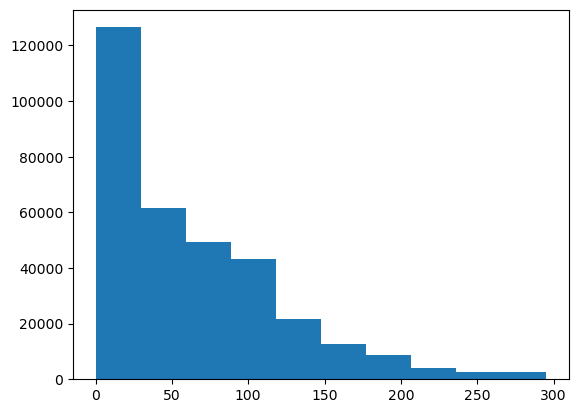

In [87]:
import matplotlib.pyplot as plt

plt.hist(df['flight_minutes'])

<Axes: xlabel='flight_minutes', ylabel='days_to_next_injury'>

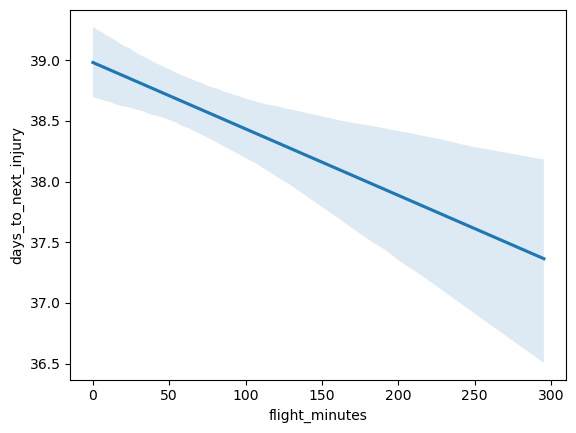

In [88]:
import seaborn as sns

sns.regplot(x=df['flight_minutes'], y = df['days_to_next_injury'], scatter=False)

<Axes: xlabel='tz_shift_hrs', ylabel='days_to_next_injury'>

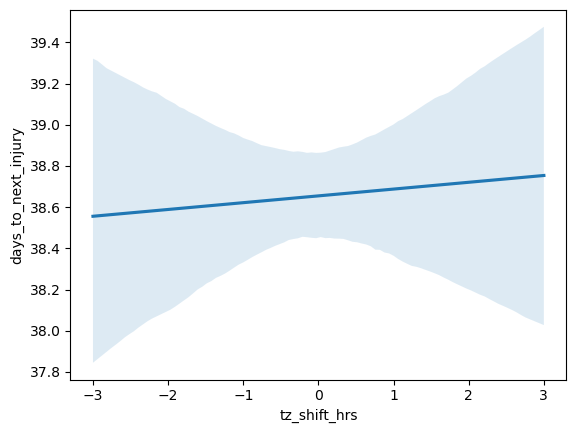

In [89]:
sns.regplot(x=df['tz_shift_hrs'], y=df['days_to_next_injury'], scatter=False)

<Axes: xlabel='tz_shift_hrs', ylabel='days_to_next_injury'>

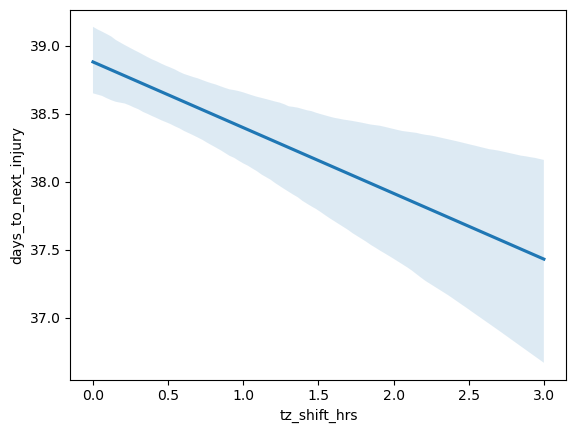

In [90]:
sns.regplot(x=abs(df['tz_shift_hrs']), y=df['days_to_next_injury'], scatter=False)

In [91]:
df['tz_shift_hrs'] = abs(df['tz_shift_hrs'])
df = df.drop(columns = [
    'game_id', 'game_date',	'month', 'week', 'opponent_abbrev', 'location'
])
for c in df.columns:
    print(c)

firstName
lastName
personId
gameId
gameDateTimeEst_player
playerteamName
gameType_player
win_player
home_player
numMinutes_player
points_player
assists_player
blocks_player
steals_player
fieldGoalsAttempted_player
fieldGoalsMade_player
fieldGoalsPercentage_player
threePointersAttempted_player
threePointersMade_player
threePointersPercentage_player
freeThrowsAttempted_player
freeThrowsMade_player
freeThrowsPercentage_player
reboundsDefensive_player
reboundsOffensive_player
reboundsTotal_player
foulsPersonal_player
turnovers_player
plusMinusPoints_player
playerteamId_player
comment
points_per36
assists_per36
blocks_per36
steals_per36
fieldGoalsAttempted_per36
fieldGoalsMade_per36
threePointersAttempted_per36
threePointersMade_per36
freeThrowsAttempted_per36
freeThrowsMade_per36
reboundsDefensive_per36
reboundsOffensive_per36
reboundsTotal_per36
foulsPersonal_per36
turnovers_per36
plusMinusPoints_per36
season_x
playerteamId_team
points_team
assists_team
blocks_team
steals_team
fieldGoalsA

In [92]:
for v in df['direction_ew'].unique():
    if v == None:
        continue
    print(v)
    print(df[df['direction_ew']==v]['days_to_next_injury'].mean())

East
38.73959314611605
N/A
38.299903283004674
West
38.90291090707295
nan
nan


East/West flights don't seem to make a difference

In [93]:
df = df.drop(columns=['season_y', 'playerteamId_team', 'firstName',
                      'lastName', 'wl', 'season_type', 'team_name',
                      'team_abbrev', 'origin_lat', 'origin_lon',
                      'dest_lat', 'dest_lon', 'timezone_origin',
                      'timezone_dest', 'flight_time', 'route', 
                      'return_home', 'days_rest'])

In [94]:
df.to_parquet('../data/Player-Games with Travel and Injuries.parquet')